In [1]:
import torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from abc import ABC, abstractmethod
from ignite.engine import Engine, Events
from ignite.handlers import ModelCheckpoint, EarlyStopping
from ignite.engine import Engine, Events, create_supervised_trainer, create_supervised_evaluator
torch.manual_seed(42)
cos = torch.nn.CosineSimilarity(dim=0, eps=1e-6)

In [2]:
test_grad = torch.tensor([0.5, 0.25, 0.25, 0.1])


In [3]:
test_grad = torch.tensor([0.5, 0.25, 0.25, 0.0]).float().to("cuda")
train_grads = torch.tensor([t for t in
    [
        *[[0, 0, 0, 1]] * 10,
        *[[1, 0 , 0, 0]] * 22,
        *[[0, 1, 0, 0]] * 33,
        *[[0, 0, 0, 1]] * 44,
        *[[0, 0, 1, 0]] * 44,
        *[[4, 4, 4, 4]] * 55
    ]
]).float().to("cuda")
factors = torch.rand(train_grads.shape[0], device="cuda")
linear_combination = (train_grads * factors.unsqueeze(1)).sum(dim=0)
cos(test_grad, linear_combination)

train_grads = train_grads[torch.randperm(train_grads.size(0)).to("cuda")]
# train_grads
# train_grads = torch.rand_like(train_grads)

In [4]:
train_grads = torch.load("/srv/home/users/loriss21cs/cfe/cache/gradients/partial/044972285b28862c/grads_rank_0.pt")[1:].to("cuda") # torch.rand(1000,2**18, device="cuda")
train_grads.shape
test_grad = train_grads[0]

In [5]:
# TODO as long as spanraum cossim will be -> 1
# --> so limit scores

In [6]:
# import logging
# logger = logging.getLogger("ignite.handlers.early_stopping.EarlyStopping")
# logger.setLevel(logging.WARNING)


In [7]:


class Optimizer(ABC, nn.Module):
    def __init__(self, train_grads, test_grad, device=None, lr=0.1):
        super().__init__()
        self.device = device
        self.lr = lr
        self.train_grads = train_grads.to(self.device)
        self.test_grad = test_grad.to(self.device)

        n_train = self.train_grads.shape[0]
        with torch.no_grad():
            # self.solution = torch.linalg.lstsq(self.train_grads.T.to(device), self.test_grad.view(-1).to(device)).solution
            # # print("self.solution",self.solution,flush=True)
            # mask = torch.empty(n_train,device=device).bernoulli_(0.5)
            # # print("sum", sum(mask),mask.shape)
            # random_values = torch.rand_like(self.solution)  

            # combined = mask * self.solution + (1 - mask) * random_values

            # self.factors = nn.Parameter(combined)#torch.clamp(combined, min=0))

            self.factors = nn.Parameter(torch.randn(n_train, device=self.device))
            # self.factors = nn.Parameter(torch.zeros(n_train, device=self.device))



        
        self.best_factors = None
        self._score = None
        self.steps_no_improve = 0
        self.fit()
    def forward(self):
        return torch.einsum('ij,i->j', self.train_grads, self.factors)
    @abstractmethod
    def loss_fct(self, test_grad, combination, reg_lambda):
        pass

    @property
    @abstractmethod
    def score(self):
        pass
    def fit(self, max_steps=10000):
        # print("start_score", self.score)
        optimizer = torch.optim.Adam([self.factors], lr=self.lr)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

        def train_step(engine, _):
            self.train()
            optimizer.zero_grad()
            loss = self.loss_fct(self.test_grad, self.forward(), self.factors)
            loss.backward()
            optimizer.step()
            with torch.no_grad():
                self.factors.clamp_(min=0)  # Enforce non-negative constraint
            return loss

        trainer = Engine(train_step)

        @trainer.on(Events.ITERATION_COMPLETED)
        def update_scheduler(engine):
            scheduler.step()

        # @trainer.on(Events.ITERATION_COMPLETED(every=1000))
        # def log_progress(engine):
        #     print(f"Step {engine.state.iteration}, Loss: {engine.state.output}")


        def score_function(engine):
            return self.score
  
        def eval_step(engine, batch):
            pass
        evaluator = Engine(eval_step)

        early_stopping = EarlyStopping(patience=100, score_function=score_function, trainer=trainer, cumulative_delta=True, min_delta=0)
        evaluator.add_event_handler(Events.COMPLETED, early_stopping)
        
        @trainer.on(Events.ITERATION_COMPLETED(every=10))
        def run_evaluator(engine):
            evaluator.run(data=[None])
            
        # @trainer.on(Events.ITERATION_COMPLETED)
        # def scheduled_noise(engine):
        #     with torch.no_grad():
        #         decay = 0.01 / (1 + engine.state.iteration / 500)
        #         self.factors.add_(torch.randn_like(self.factors) * decay)
        #         self.factors.clamp_(min=0)

        trainer.run(data=[None] * 100, max_epochs=max_steps//100)


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from ignite.engine import Engine, Events
from ignite.handlers import EarlyStopping


class OptimizerKLT(Optimizer):
    def __init__(self, train_grads, test_grad, device=None, lr=0.1, reg_lambda=0.05 ):
        self.reg_lambda = reg_lambda
        self.best_factors = None
        self.steps_no_improve = 0
        super().__init__(train_grads, test_grad, device)
        with torch.no_grad():
            num_samples, dim = train_grads.shape
            mean = train_grads.mean(dim=0, keepdim=True)
            centered = train_grads - mean
            cov = centered.T @ centered / (num_samples - 1)
            eigvals, eigvecs = torch.linalg.eigh(cov)
            eigvals = eigvals.flip(dims=[0])
            eigvecs = eigvecs.flip(dims=[1])
            self.klt_basis = eigvecs 
            coeffs = self.klt_basis.T @ test_grad.view(-1)
            self.factors = nn.Parameter(coeffs)
    def loss_fct(self, test_grad, combination, factors, alpha=0.5): 
        pass
    def fit(self, max_steps=1000):
        pass
    @property
    def score(self):
        with torch.no_grad():
            return F.mse_loss(self.klt_basis @ self.factors, test_grad)
    


class OptimizerCosineL1(Optimizer):
    def __init__(self, train_grads, test_grad, device=None, lr=0.1, reg_lambda=0.05 ):
        self.reg_lambda = reg_lambda
        self.best_factors = None
        self.steps_no_improve = 0
        super().__init__(train_grads, test_grad, device)

    def loss_fct(self, test_grad, combination, factors, alpha=0.5): 
        return -F.cosine_similarity(test_grad.unsqueeze(0), combination.unsqueeze(0)) + self.reg_lambda * factors.sum()
    @property
    def score(self):
        with torch.no_grad():
            return F.cosine_similarity(self.test_grad.unsqueeze(0), self.forward().unsqueeze(0)).cpu().item()


class OptimizerCrossEntropyL1(Optimizer):
    def __init__(self, train_grads, test_grad, device=None, lr=0.1, reg_lambda=0.1 ):
        self.reg_lambda = reg_lambda
        self.best_factors = None
        self.steps_no_improve = 0
        super().__init__(train_grads, test_grad, device)

    def loss_fct(self, test_grad, combination, factors): 
        l = -F.cross_entropy(test_grad.unsqueeze(0), combination.unsqueeze(0)) + self.reg_lambda * factors.sum()
        return l
    @property
    def score(self):
        with torch.no_grad():
            return F.cross_entropy(self.test_grad.unsqueeze(0), self.forward().unsqueeze(0)).cpu().item()


    
class OptimizerMSEL1(Optimizer):
    def __init__(self, train_grads, test_grad, device=None, lr=0.1, reg_lambda=0.05):
        self.reg_lambda = reg_lambda
        self.best_factors = None
        self.steps_no_improve = 0
        super().__init__(train_grads, test_grad, device)

    def loss_fct(self, test_grad, combination, factors):
        mse_loss = F.mse_loss(combination, test_grad)
        return mse_loss + self.reg_lambda * factors.sum()
    @property
    def score(self):
        with torch.no_grad():
            return F.mse_loss(self.test_grad.unsqueeze(0), self.forward().unsqueeze(0)).cpu().item()


class OptimizerMSEL0(Optimizer):
    def __init__(self, train_grads, test_grad, device=None, lr=0.1, reg_lambda=0.1):
        self.reg_lambda = reg_lambda
        self.best_factors = None
        self.steps_no_improve = 0
        super().__init__(train_grads, test_grad, device)

    def loss_fct(self, test_grad, combination, factors):
        mse_loss = F.mse_loss(combination, test_grad)
        return mse_loss + self.reg_lambda * torch.count_nonzero(factors)
    @property
    def score(self):
        with torch.no_grad():
            return F.mse_loss(self.test_grad.unsqueeze(0), self.forward().unsqueeze(0)).cpu().item()

class OptimizerLemon(Optimizer):
    def __init__(self, train_grads, test_grad, device=None, lr=0.1, reg_lambda=1):
        self.reg_lambda = reg_lambda
        self.best_factors = None
        self.steps_no_improve = 0
        super().__init__(train_grads, test_grad, device)

    def loss_fct(self, test_grad, combination, factors):
        mse_loss = F.mse_loss(combination, test_grad)
        return mse_loss + self.reg_lambda * torch.count_nonzero(factors > 0.01)
    @property
    def score(self):
        with torch.no_grad():
            return F.mse_loss(self.test_grad.unsqueeze(0), self.forward().unsqueeze(0)).cpu().item()

# OptimizerCosineL1(train_grads[2:].to("cuda"), train_grads[0].to("cuda"), lr=0.1,reg_lambda=0, device="cuda")         


In [9]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

device = "cuda"


# train_grads = torch.rand(500,10000, device=device)
# train_grads = torch.load("/srv/home/users/loriss21cs/cfe/cache/gradients/partial/044972285b28862c/grads_rank_0.pt").to(device)

print(train_grads.shape)
n_train = train_grads.shape[0] - 1
print("n_train",n_train)
test_indices = [0,1,2]# list(range(n_train))
ms = [1,2,3,4,5]




torch.Size([99, 8192])
n_train 98


In [10]:
train_grads

tensor([[ 0.0098,  0.0187,  0.0077,  ...,  0.0214, -0.0094,  0.0158],
        [-0.0177,  0.0200, -0.0179,  ...,  0.0041,  0.0032,  0.0033],
        [ 0.0049,  0.0244,  0.0121,  ..., -0.0098,  0.0090,  0.0073],
        ...,
        [ 0.0016,  0.0096, -0.0080,  ...,  0.0035,  0.0038, -0.0053],
        [ 0.0154,  0.0077,  0.0238,  ...,  0.0319, -0.0064, -0.0150],
        [ 0.0229,  0.0104,  0.0087,  ...,  0.0184, -0.0053, -0.0112]],
       device='cuda:0')

In [11]:
from collections import defaultdict


In [17]:
pred_gains = defaultdict(list)

methods = [OptimizerCosineL1, OptimizerCrossEntropyL1, OptimizerMSEL1]
for k in range(4,10):#len(train_grads)+1):
    train_set = train_grads[0:k]
    x = test_grad
    # klt
    o = OptimizerKLT(train_set, test_grad, device="cuda",reg_lambda=0.00, lr=0.05)
    x_hat = o.klt_basis @ o.factors
    var_pred_error = torch.var(x-x_hat,correction=0)
    pred_gain_klt  = torch.var(x,correction=0) / var_pred_error
    
    def process_method(method, train_set, test_grad, pred_gain_klt):
        o = method(train_set, test_grad, device="cuda", reg_lambda=0.00, lr=0.05)
        x_hat = torch.einsum('ij,i->j', o.train_grads, o.factors)
        var_pred_error = torch.var(test_grad - x_hat, correction=0)
        pred_gain = torch.var(test_grad, correction=0) / var_pred_error
        normalized_gain = pred_gain / pred_gain_klt
        return method.__name__, normalized_gain

    with ThreadPoolExecutor() as executor:
        futures = [
            executor.submit(process_method, method, train_set, test_grad, pred_gain_klt)
            for method in methods
        ]
        results = [future.result() for future in futures]  # preserves order
        for method_name, normalized_gain in results:
            pred_gains[method_name].append(normalized_gain)

pred_gains = {method : torch.tensor(p) for method, p in pred_gains.items()}

2025-08-04 13:52:20,802 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training
2025-08-04 13:52:20,910 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training
2025-08-04 13:52:21,326 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training
2025-08-04 13:52:24,696 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training
2025-08-04 13:52:24,806 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training
2025-08-04 13:52:25,305 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training
2025-08-04 13:52:28,987 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training
2025-08-04 13:52:28,990 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training
2025-08-04 13:52:29,018 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training
2025-08-04 13:52:32,723 ignite.handlers.early_stopping.EarlyStop

In [13]:
pred_gains

{'OptimizerCosineL1': tensor([7.8470e-13, 7.8191e-12, 4.2755e-13, 1.7535e-13, 3.6661e-13, 7.2068e-13]),
 'OptimizerCrossEntropyL1': tensor([1.4608e-12, 1.3892e-12, 1.3266e-12, 1.3129e-12, 1.2996e-12, 1.9179e-12]),
 'OptimizerMSEL1': tensor([1.0901e+02, 2.0799e+08, 1.7096e+08,        inf, 4.0979e+01,        inf])}

In [14]:
pred_gains

{'OptimizerCosineL1': tensor([7.8470e-13, 7.8191e-12, 4.2755e-13, 1.7535e-13, 3.6661e-13, 7.2068e-13]),
 'OptimizerCrossEntropyL1': tensor([1.4608e-12, 1.3892e-12, 1.3266e-12, 1.3129e-12, 1.2996e-12, 1.9179e-12]),
 'OptimizerMSEL1': tensor([1.0901e+02, 2.0799e+08, 1.7096e+08,        inf, 4.0979e+01,        inf])}

<Axes: >

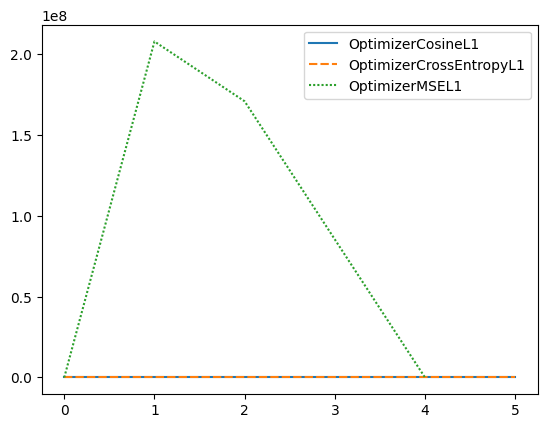

In [15]:
sns.lineplot(pred_gains)
# plt.ylim(0,1e-14)

In [16]:
9zrfu0piü

SyntaxError: invalid decimal literal (3575310142.py, line 1)

In [ ]:


# # Function to compute scores for a single test_idx
# def process_test_idx(test_idx):
#     results = []
#     test_grad = train_grads[test_idx]
#     train_subset = torch.cat([train_grads[:test_idx], train_grads[test_idx+1:]], dim=0)

#     for m in ms:
#         random_subset = train_subset[torch.randperm(train_subset.size(0), device=device)[:m]]
#         assert random_subset.shape[0] == m
#         optimizer_model = OptimizerCrossEntropy(random_subset, test_grad, l1_lambda=0.05, lr=0.1, device=device)
#         score = optimizer_model.score
#      #   print(f"Test idx {test_idx}, m = {m}, score = {score}")
#         results.append({'test_idx': test_idx, 'subset_size': m, 'score': score})
#     return results


# all_scores = []
# with ThreadPoolExecutor() as executor:
#     futures = [executor.submit(process_test_idx, test_idx) for test_idx in test_indices]
#     for future in as_completed(futures):
#         all_scores.extend(future.result())

# # Create DataFrame
# df = pd.DataFrame(all_scores)

# # Plot
# plt.figure(figsize=(8, 5))
# sns.lineplot(data=df, x='subset_size', y='score', hue='test_idx', marker='o')
# plt.xlabel('Subset size (m)')
# plt.ylabel('Score')
# plt.title('Score vs Subset size for Different Test Gradients')
# # plt.xscale('log')
# plt.legend(title='Test Index')
# plt.show()


In [ ]:


# Function to compute scores for a single test_idx
def process_test_idx(test_idx):
    results = []
    test_grad = train_grads[test_idx]
    train_subset = torch.cat([train_grads[:test_idx], train_grads[test_idx+1:]], dim=0)

    for m in ms:
        random_subset = train_subset[torch.randperm(train_subset.size(0), device=device)[:m]]
        assert random_subset.shape[0] == m
        optimizer_model = OptimizerCosineL1(random_subset, test_grad, reg_lambda=0.05, lr=0.1, device=device)
        score = optimizer_model.score
        print(f"Test idx {test_idx}, m = {m}, score = {score}")
        results.append({'test_idx': test_idx, 'subset_size': m, 'score': score})
    return results


all_scores = []
with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_test_idx, test_idx) for test_idx in test_indices]
    for future in as_completed(futures):
        all_scores.extend(future.result())

# Create DataFrame
df = pd.DataFrame(all_scores)

# Plot
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x='subset_size', y='score', hue='test_idx', marker='o')
plt.xlabel('Subset size (m)')
plt.ylabel('Score')
plt.title('Score vs Subset size for Different Test Gradients')
# plt.xscale('log')
plt.legend(title='Test Index')
plt.show()


Test idx 0, m = 1, score = 1.0
Test idx 2, m = 1, score = 1.0
Test idx 1, m = 1, score = 1.0
Test idx 1, m = 2, score = 0.0
Test idx 0, m = 2, score = 1.0
Test idx 2, m = 2, score = 1.0


Test idx 2, m = 3, score = 0.5852057337760925


In [ ]:
# import torch
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pandas as pd

# train_grads = torch.load("/srv/home/users/loriss21cs/cfe/cache/gradients/partial/044972285b28862c/grads_rank_0.pt") # torch.rand(1000,2**18, device="cuda")

# print(train_grads.shape)
# device = train_grads.device
# n_train = train_grads.shape[0] - 1
# test_indices = [0, 5, 10, 99] 
# ms = [2, 5, 10, 20, 100, 200, 500, 1000, n_train]

# # Collect results
# all_scores = []

# for test_idx in test_indices:
#     test_grad = train_grads[test_idx]
#     train_subset = torch.cat([train_grads[:test_idx], train_grads[test_idx+1:]], dim=0)  
#     scores = []

#     for m in ms:
#         random_subset = train_subset[torch.randperm(train_subset.size(0), device=device)[:m]]
#         optimizer_model = FactorOptimizer(random_subset, test_grad, l1_lambda=0.05, lr=0.1, device=device)
#         scores.append(optimizer_model.score)
#         print(f"Test idx {test_idx}, m = {m}, score = {optimizer_model.score}")

#     for m, score in zip(ms, scores):
#         all_scores.append({'test_idx': test_idx, 'subset_size': m, 'score': score})

# # Create DataFrame
# df = pd.DataFrame(all_scores)

# # Plot
# plt.figure(figsize=(8, 5))
# sns.lineplot(data=df, x='subset_size', y='score', hue='test_idx', marker='o')
# plt.xlabel('Subset size (m)')
# plt.ylabel('Score')
# plt.title('Score vs Subset size for Different Test Gradients')
# # plt.xscale('log')
# plt.legend(title='Test Index')
# plt.show()
